# Churn Prediction — Your First Classification Project

**Dataset:** Telco customer churn (a subscription service). Predict whether a customer leaves (`Churn` = Yes/No).

**New vs. your regression projects:** the target is now a *category*, not a number. That changes how you prep the data and — most importantly — how you measure success.

## The workflow
1. Load & look
2. Clean `TotalCharges`
3. The target: churn rate (mind the imbalance)
4. Explore: who churns?
5. Prep features (encode text → numbers)
6. Train/test split (stratified)
7. Scale + train Logistic Regression
8. Evaluate (why accuracy lies)
9. Improve

In [3]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 7.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")

Shape: (7043, 21)


## 1. Look at the data

In [54]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
# Check dtypes — one numeric column is secretly stored as text. Spot which.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Clean `TotalCharges`

**Why:** ~11 rows have a blank string instead of a number (new customers, tenure = 0). That forces the whole column to `object`. Convert it to numeric.

In [56]:
# Convert TotalCharges to a real number; blanks become NaN
# Hint: df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].dtypes




dtype('float64')

In [57]:
# How many NaN did that create? Then fill them with 0 (tenure=0 → no charges yet)
# Hint: df['TotalCharges'].isna().sum()  ... then df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isna().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"the total na in the charge column is {df['TotalCharges'].isna().sum()}")


the total na in the charge column is 0


## 3. The target: churn rate

**Why it matters:** if only ~1 in 4 customers churn, a lazy model that predicts *"nobody churns"* is already ~73% accurate. Keep that baseline in mind — it's why accuracy alone will fool you later.

In [58]:
# What % of customers churned? (normalize gives proportions, not counts)
# Hint: df['Churn'].value_counts(normalize=True)
print(df['Churn'].unique())
df['Churn'] = df['Churn'].apply(lambda x: 1 if x =='Yes' else 0)





<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [59]:
df.groupby(['Churn'])['customerID'].nunique()
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [60]:
df['Churn'].value_counts(normalize=True)



Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn'>

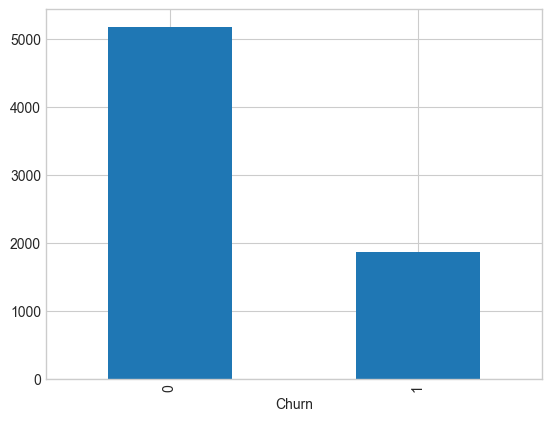

In [61]:
# Bar chart of churn counts (Yes vs No)
# Hint: df['Churn'].value_counts().plot.bar()
df['Churn'].value_counts().plot.bar()


## 4. Explore: who churns?

Find the strongest churn drivers. Charts > tables for you.

In [62]:
# Churn RATE by contract type — crosstab normalized across each row
# Hint: pd.crosstab(df['Contract'], df['Churn'], normalize='index')
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: title={'center': 'tenure'}, xlabel='Churn'>

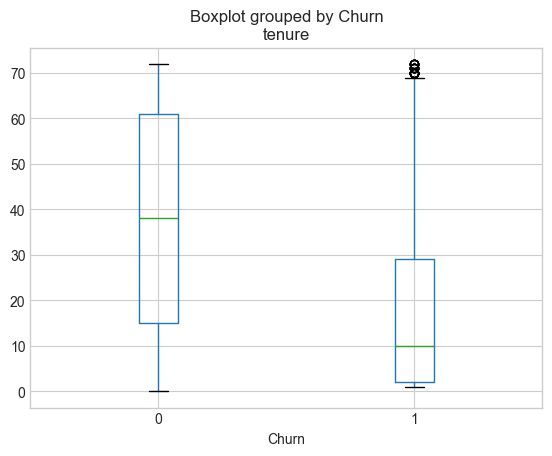

In [63]:
# Does tenure differ for churners vs stayers? Compare the distributions.
# Hint: df.boxplot(column='tenure', by='Churn')
df.boxplot(column='tenure', by='Churn')

In [64]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [65]:
pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize ='index')

Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [42]:
pd.crosstab(df['MultipleLines'],df['Churn'],normalize ='index')


Churn,0,1
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


In [66]:
pd.crosstab(df['PhoneService'],df['Churn'],normalize ='index')


Churn,0,1
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096


In [67]:
pd.crosstab(df['InternetService'],df['Churn'],normalize ='index')


Churn,0,1
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [68]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize ='index')


Churn,0,1
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


## 5. Prep features

Models need numbers, not text. Two jobs: (a) turn the target into 0/1, (b) one-hot encode the text columns.

In [52]:
# Target → numbers, and drop the ID column (it's not a feature)
# Hint: df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})  ... then df = df.drop(columns='customerID')
df = df.drop(columns='customerID')

KeyError: "['customerID'] not found in axis"

In [51]:
# One-hot encode the remaining text columns into 0/1 dummy columns
# Hint: df = pd.get_dummies(df, drop_first=True)   # drop_first avoids redundant columns
# Then check: df.shape  (many more columns now)
df = pd.get_dummies(df,drop_first= True).astype(int)
df.shape


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [50]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 6. Train/test split — stratified

**Why `stratify=y`:** with an imbalanced target, a random split could land most churners in one set. Stratifying keeps the ~27% churn ratio identical in train and test.

In [ ]:
from sklearn.model_selection import train_test_split

# X = all features except Churn,  y = Churn
# Hint: X = df.drop(columns='Churn');  y = df['Churn']
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


## 7. Scale + train Logistic Regression

**Why scale:** logistic regression is sensitive to feature ranges (tenure 0–72 vs TotalCharges 0–8000). Standardize so no feature dominates by size alone. Fit the scaler on **train only**, then apply to test.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Hint: scaler = StandardScaler()
# Hint: X_train_s = scaler.fit_transform(X_train)
# Hint: X_test_s  = scaler.transform(X_test)   # transform only — no fit on test!


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train on the scaled training data
# Hint: model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)


## 8. Evaluate — why accuracy lies

**The lesson:** compare your accuracy to the ~73% "predict everyone stays" baseline. Beating it a little isn't enough — you care about *catching churners*. That's **recall** (of the churners, how many did you flag?) and **precision** (of the ones you flagged, how many really churned?).

In [ ]:
# Accuracy on the test set — then ask: is it really better than 73%?
# Hint: model.score(X_test_s, y_test)


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix: rows = actual, cols = predicted. Look at the churn row.
# Hint: ConfusionMatrixDisplay.from_estimator(model, X_test_s, y_test)


In [ ]:
from sklearn.metrics import classification_report

# Precision / recall / F1 per class. Focus on the '1' (churn) row.
# Hint: print(classification_report(y_test, model.predict(X_test_s)))


In [ ]:
from sklearn.metrics import RocCurveDisplay

# ROC curve + AUC — how well does the model rank churners above stayers?
# Hint: RocCurveDisplay.from_estimator(model, X_test_s, y_test)


## 9. Improve

More open-ended now — experiment and compare **recall on churn**, not just accuracy.

In [ ]:
# The model probably misses lots of churners. Re-train telling it churn matters more.
# Hint: class_weight='balanced'  inside LogisticRegression(...). Re-check the classification_report.


In [ ]:
# Try a different model and compare. Does it catch more churners?
# Hint: from sklearn.ensemble import RandomForestClassifier  (tree models don't need scaling — use X_train/X_test)


## Quiz — check yourself

1. The baseline "predict no one churns" scores ~73% accuracy. In one sentence, why is that model useless to the business?
2. A model has 95% precision but 20% recall on churn. What is it doing — and is that good for a retention team?
3. Why did we fit `StandardScaler` on the training set only?
4. What does `stratify=y` protect against here?
5. `class_weight='balanced'` usually raises recall but lowers precision. Why is that trade-off often worth it for churn?